In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import pandas as pd

In [2]:
df=pd.read_csv("../data/Crop_recommendation.csv")

In [3]:
print(df.describe())
print("Duplicates:", df.duplicated().sum())
print(df["label"].value_counts().head())

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  
Duplicates: 0
label
rice   

In [4]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # learn scaling from train only
X_test_s = scaler.transform(X_test)         # apply same scaling to test

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)

print("LR train acc:", lr.score(X_train_s, y_train))
print("LR test acc:", lr.score(X_test_s, y_test))

LR train acc: 0.9738636363636364
LR test acc: 0.9727272727272728


In [7]:
params = {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
gs = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5)
gs.fit(X_train, y_train)
rf = gs.best_estimator_

print("Best params:", gs.best_params_)
print("RF train acc:", rf.score(X_train, y_train))
print("RF test acc:", rf.score(X_test, y_test))

Best params: {'max_depth': None, 'n_estimators': 200}
RF train acc: 1.0
RF test acc: 0.9954545454545455


In [8]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr.predict(X_test_s)))
print("RANDOM FOREST")
print(classification_report(y_test, rf.predict(X_test)))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      p

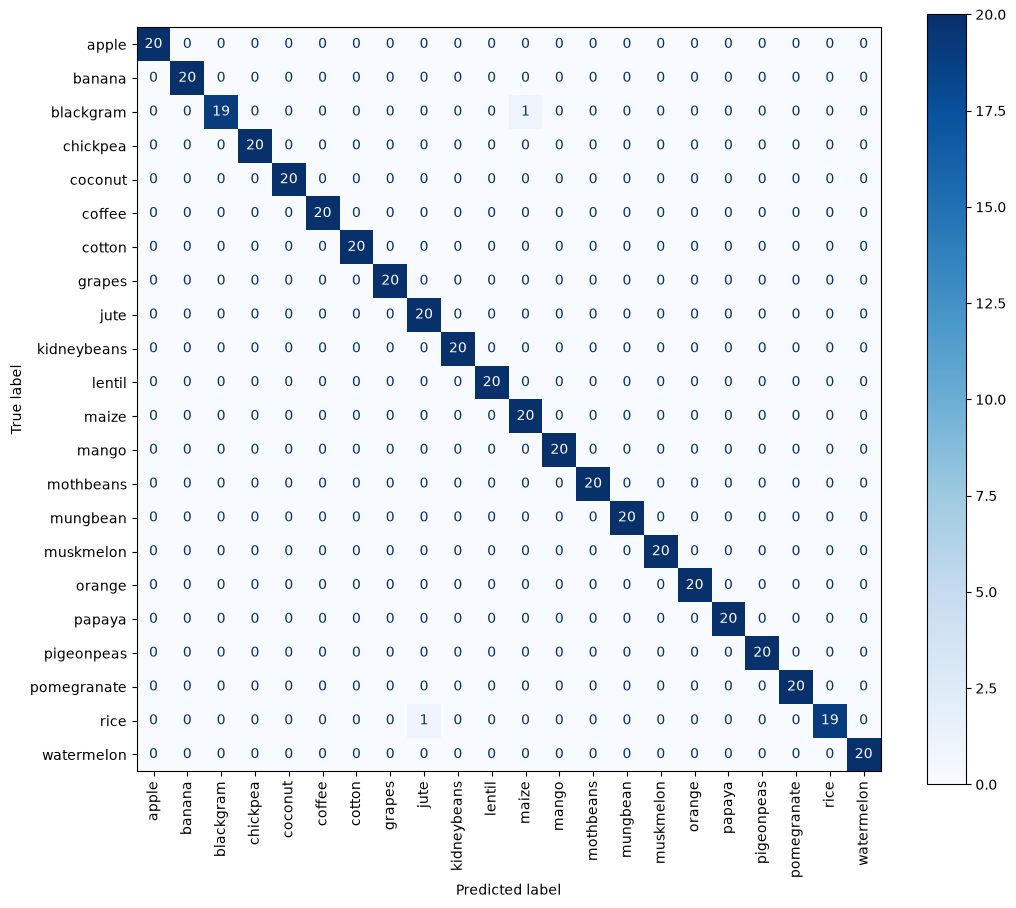

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test),
    labels=rf.classes_, cmap="Blues",
    xticks_rotation=90, ax=ax)
plt.show()

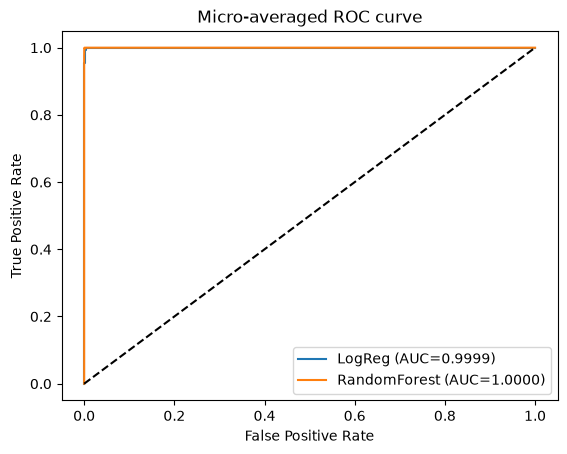

In [10]:
y_bin = label_binarize(y_test, classes=rf.classes_)   # one column per crop

proba_lr = lr.predict_proba(X_test_s)
proba_rf = rf.predict_proba(X_test)

# micro-average: treat all (sample, crop) pairs as one big binary problem
fpr_lr, tpr_lr, _ = roc_curve(y_bin.ravel(), proba_lr.ravel())
fpr_rf, tpr_rf, _ = roc_curve(y_bin.ravel(), proba_rf.ravel())

auc_lr = roc_auc_score(y_bin, proba_lr, average="micro")
auc_rf = roc_auc_score(y_bin, proba_rf, average="micro")

plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={auc_rf:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC curve")
plt.legend()
plt.show()

In [11]:
import joblib

joblib.dump(rf, "../model/crop_rf_model.pkl", compress=3)
print("Saved!")

Saved!


## Top-3 crop recommendation
Uses `predict.py`, which loads the saved model and returns the 3 most likely crops with confidence.

In [12]:
import sys
sys.path.append("..")
from cropwise.predict import recommend_top_k

sample = {"N": 90, "P": 42, "K": 43, "temperature": 20.9,
          "humidity": 82, "ph": 6.5, "rainfall": 203}
result = recommend_top_k(sample, k=3)

for rank, item in enumerate(result["top"], 1):
    print(f"{rank}. {item['crop']:<12} {item['confidence']:.1%}")
for w in result["warnings"]:
    print("Warning:", w)


1. rice         93.5%
2. jute         6.5%
3. pomegranate  0.0%
